### Exploratory Data Analyst para dataset de *neighbourhoods*

### 📋 Descripción del Dataset: `neighbourhoods.csv` (Málaga)

El dataset contiene los distritos municipales de la ciudad de **Málaga**. Este archivo servirá como base para categorizar la ubicación de los alojamientos en nuestro pipeline.

| # | neighbourhood_group | neighbourhood |
|:---:|:---:|:---|
| 0 | NaN | Bailen-Miraflores |
| 1 | NaN | Campanillas |
| 2 | NaN | Carretera de Cadiz |
| 3 | NaN | Centro |
| 4 | NaN | Churriana |
| 5 | NaN | Ciudad Jardin |
| 6 | NaN | Cruz De Humilladero |
| 7 | NaN | Este |
| 8 | NaN | Palma-Palmilla |
| 9 | NaN | Puerto de la Torre |
| 10 | NaN | Teatinos-Universidad |

---

### 🔍 Diagnóstico Inicial del EDA

1. **Datos Faltantes:** Al igual que en otros datasets de Airbnb, `neighbourhood_group` está vacío (**11 nulos**). Esto nos permite proponer una tarea de **Transformación** en Airflow para agrupar los distritos por zonas geográficas.
2. **Consistencia:** Los nombres siguen la nomenclatura oficial de distritos de Málaga. Se validará que no existan errores de formato en la carga.
3. **Propuesta de Valor:** Clasificaremos los distritos en **"Litoral"** (con acceso a costa) e **"Interior"**, o por zonas (Centro, Oeste, Este, Periferia) para enriquecer el análisis.

In [16]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

path = "../data/"

neighbourhoods = pd.read_csv(os.path.join(path, "neighbourhoods.csv"))

print(neighbourhoods.head(5), "\n")

print(neighbourhoods.info())


   neighbourhood_group       neighbourhood
0                  NaN   Bailen-Miraflores
1                  NaN         Campanillas
2                  NaN  Carretera de Cadiz
3                  NaN              Centro
4                  NaN           Churriana 

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   neighbourhood_group  0 non-null      float64
 1   neighbourhood        11 non-null     str    
dtypes: float64(1), str(1)
memory usage: 308.0 bytes
None


In [3]:
# Ver cuantos barrios unicos hay
barrios_unicos = neighbourhoods["neighbourhood"].unique()
print(len(barrios_unicos), "barrios únicos\n")
print(barrios_unicos)


11 barrios únicos

<StringArray>
[   'Bailen-Miraflores',          'Campanillas',   'Carretera de Cadiz',
               'Centro',            'Churriana',        'Ciudad Jardin',
  'Cruz De Humilladero',                 'Este',       'Palma-Palmilla',
   'Puerto de la Torre', 'Teatinos-Universidad']
Length: 11, dtype: str


In [4]:
# Ver si hay columnas totalmente vacías (Missing values)
print("\n- Informe de Valores Nulos")
print(neighbourhoods.isnull().sum())


- Informe de Valores Nulos
neighbourhood_group    11
neighbourhood           0
dtype: int64


In [ ]:
GRUPOS_BARRIOS = {
    "Centro"   : ["Centro"],
    "Este"     : ["Este"],
    "Oeste"    : ["Carretera de Cadiz", "Cruz De Humilladero", "Teatinos-Universidad", "Churriana", "Campanillas", "Puerto de la Torre"],
    "Norte"    : ["Bailen-Miraflores", "Palma-Palmilla", "Ciudad Jardin"],
}

# Construir mapa inverso: {barrio: grupo}
mapa_barrio_grupo = {
    barrio: grupo
    for grupo, barrios in GRUPOS_BARRIOS.items()
    for barrio in barrios
}

neighbourhoods["neighbourhood_group"] = (
    neighbourhoods["neighbourhood"].map(mapa_barrio_grupo)
)

In [9]:
# Cargar listings y cruzarlos con neighbourhoods
listings = pd.read_csv(os.path.join(path, "listings.csv"))

listings['neighbourhood_group_cleansed'] = (
    listings["neighbourhood_cleansed"].map(mapa_barrio_grupo)
)

# Listings por barrio
listings_por_barrio = listings["neighbourhood_cleansed"].value_counts().reset_index()
listings_por_barrio.columns = ["neighbourhood", "n_listings"]

print(listings_por_barrio.to_string(index=False))

       neighbourhood  n_listings
              Centro        6389
                Este         989
  Carretera de Cadiz         935
 Cruz De Humilladero         460
   Bailen-Miraflores         312
      Palma-Palmilla         217
           Churriana         150
Teatinos-Universidad         100
       Ciudad Jardin          88
  Puerto de la Torre          41
         Campanillas          33


/tmp/ipykernel_27416/2312081826.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


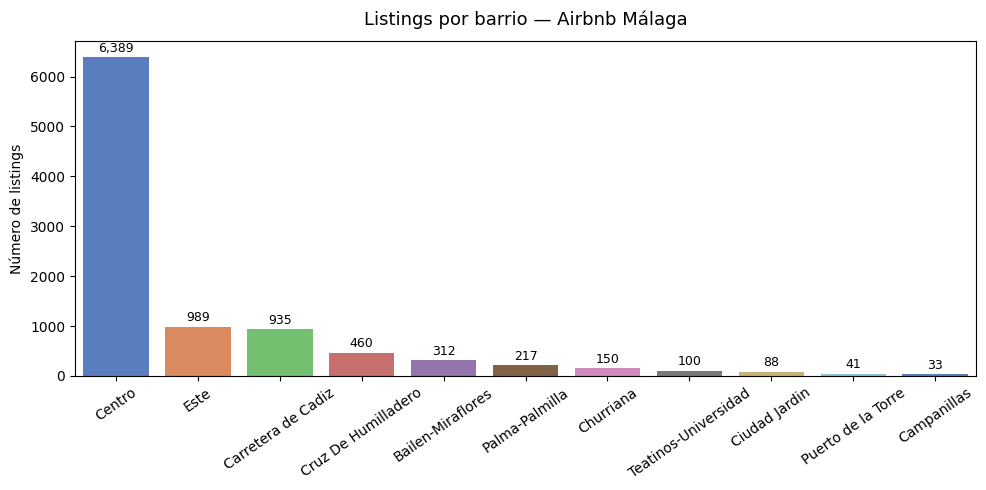

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

barrios_ord = listings_por_barrio.sort_values("n_listings", ascending=False)

sns.barplot(
    data=barrios_ord,
    x="neighbourhood",
    y="n_listings",
    palette="muted",
    ax=ax
)

ax.set_title("Listings por barrio — Airbnb Málaga", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Número de listings")
ax.tick_params(axis="x", rotation=35)

# Etiquetas encima de cada barra
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()

In [12]:
# Listings por barrio
listings_por_grupo_barrio = listings["neighbourhood_group_cleansed"].value_counts().reset_index()
listings_por_grupo_barrio.columns = ["neighbourhood_group_cleansed", "n_listings"]

print(listings_por_grupo_barrio.to_string(index=False))

neighbourhood_group_cleansed  n_listings
                      Centro        6389
                       Oeste        1719
                        Este         989
                       Norte         617


In [ ]:
listings_por_grupo_barrio[listings_por_grupo_barrio['neighbourhood_group_cleansed'] == 'Centro']['n_listings']

0    6389
Name: n_listings, dtype: int64

In [17]:
np.sum(listings_por_grupo_barrio[listings_por_grupo_barrio['neighbourhood_group_cleansed'] != 'Centro']['n_listings'])

np.int64(3325)

ValueError: Could not interpret value `neighbourhood_group` for `x`. An entry with this name does not appear in `data`.

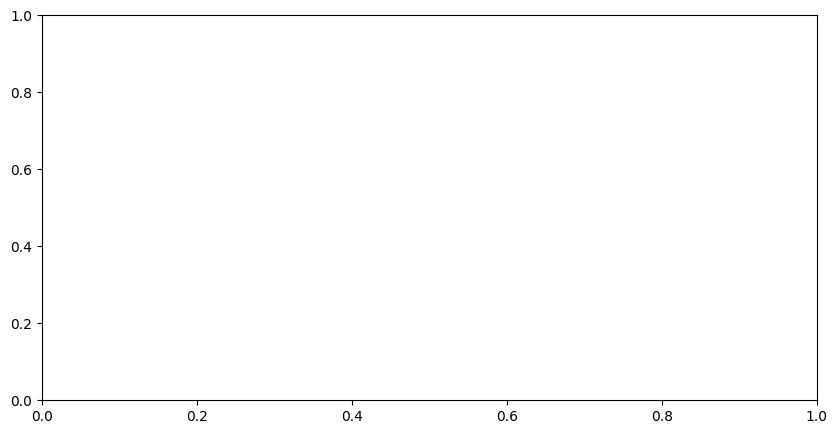

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

barrios_ord = listings_por_grupo_barrio.sort_values("n_listings", ascending=False)

sns.barplot(
    data=barrios_ord,
    x="neighbourhood_group",
    y="n_listings",
    palette="muted",
    ax=ax
)

ax.set_title("Listings por barrio — Airbnb Málaga", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Número de listings")
ax.tick_params(axis="x", rotation=35)

# Etiquetas encima de cada barra
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
# Comprobamos que los barrios coincidan
barrios_csv     = set(neighbourhoods["neighbourhood"].str.strip())
barrios_listing = set(listings["neighbourhood_cleansed"].dropna().str.strip().unique())

print("En CSV pero NO en listings:", barrios_csv - barrios_listing)
print("En listings pero NO en CSV:", barrios_listing - barrios_csv)
# Si ambos salen vacíos, perfecta consistencia entre ficheros

In [ ]:
# Vemos estadísiticas del precio por barrio

listings['price_num'] = listings['price'].replace(r'[\$,]', '', regex=True).astype(float)

precio_por_barrio = (
    listings.groupby("neighbourhood_cleansed")["price_num"]
    .agg(
        precio_medio="mean",
        precio_mediano="median",
        precio_min="min",
        precio_max="max"
    ).round(1).reset_index().sort_values("precio_mediano", ascending=False)
)

print(precio_por_barrio.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=precio_por_barrio,
    x="neighbourhood_cleansed",
    y="precio_medio",
    palette="flare",
    ax=ax
)

ax.set_title("Precio medio por barrio (€)", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("€")
ax.tick_params(axis="x", rotation=35)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"€{int(bar.get_height())}",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
room_type = (
    listings.groupby(["neighbourhood_cleansed", "room_type"])
    .size()
    .unstack(fill_value=0)
)

# Ordenar por total de listings
room_type = room_type.loc[
    room_type.sum(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(11, 5))
room_type.plot(kind="bar", stacked=True, ax=ax,
               colormap="tab10", edgecolor="white")

ax.set_title("Tipo de alojamiento por barrio", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Número de listings")
ax.tick_params(axis="x", rotation=35)
ax.legend(title="Tipo", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
disponibilidad = (
    listings.groupby("neighbourhood_cleansed")["availability_365"]
    .mean()
    .round(1)
    .reset_index()
    .rename(columns={"availability_365": "disponibilidad_media"})
    .sort_values("disponibilidad_media", ascending=False)
)

# Color por nivel
colores = [
    "#d9534f" if v < 150 else "#5cb85c" if v > 230 else "#aaaaaa"
    for v in disponibilidad["disponibilidad_media"]
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    disponibilidad["neighbourhood_cleansed"],
    disponibilidad["disponibilidad_media"],
    color=colores, edgecolor="white"
)

media_global = disponibilidad["disponibilidad_media"].mean()
ax.axhline(media_global, color="gray", linestyle="--",
           linewidth=1, label=f"Media global: {media_global:.0f} días")

ax.set_title("Disponibilidad media (días/año)", fontsize=13, pad=12)
ax.set_ylabel("Días disponibles")
ax.set_ylim(100, 270)
ax.tick_params(axis="x", rotation=35)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()